# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [ ]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 461kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)  # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `encode`는 입력 데이터 `x`를 latent space의 분포를 나타내는  평균 `mu`와 로그 분산`logvar`로 변환하는 역할을 한다.`fc1`과 `ReLU`를 통해 입력 데이터를 `h1`로 변환하고 `fc21(h1)`을 통해 `logvar`를 계산한다.
*  `reparameterize`는 `mu`와 `logvar`를 받아 `std = torch.exp(0.5 * logvar)`와 `torch.randn_like(std)`를 계산하여 랜덤 노이즈 `eps`를 생성한다 이후 `z = mu + eps * std`를 계산하는 Reparameterization Trick을 사용하여 잠재변수를 얻는다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [ ]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `elbo_loss`는 학습 과정에서 원본 이미지와 복원된 이미지의 오차를 줄이는 동시에 잠재공간의 분포가 표준 정규분포에 가깝도록 학습시키는 역할을 한다. `binary_cross_entropy`를 통해 원본 이미지 `x`와 복원된 이미지 `recon_x`의 차이를 계산하며, `mu`와 `logvar`를 이용해 KL Divergence를 계산한다. 마지막으로 `BCE`와 `KLD`를 더히여 최종 loss를 계산한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* KL Divergence는 Encoder가 만들어내는 잠재분포가 표준 정규분포와 비슷하도록 만든다. 따라서 VAE의 ELBO Loss에서 BCE 항만 포함하게 되면 모델은 입력 이미지를 잘 복원하는 것에만 집중하기 때문에 잠재공간이 불규칙하게 형성될 수 있다. 이렇게 되면 표준 정규분포에서 랜덤하게 샘플링한 잠재벡터를 Decoder에 입력하여 새로운 이미지를 생성하기 어려워지기 때문에 KL Divergence를 추가하여 잠재분포를 표준 정규분포에 가깝게 만드는 과정이 필요하다.


In [ ]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3082 | Val Loss: 1.0307
Epoch [2/15] Train Loss: 0.9620 | Val Loss: 0.9319
Epoch [3/15] Train Loss: 0.9040 | Val Loss: 0.8993
Epoch [4/15] Train Loss: 0.8796 | Val Loss: 0.8811
Epoch [5/15] Train Loss: 0.8646 | Val Loss: 0.8695
Epoch [6/15] Train Loss: 0.8547 | Val Loss: 0.8600
Epoch [7/15] Train Loss: 0.8474 | Val Loss: 0.8550
Epoch [8/15] Train Loss: 0.8421 | Val Loss: 0.8524
Epoch [9/15] Train Loss: 0.8372 | Val Loss: 0.8472
Epoch [10/15] Train Loss: 0.8339 | Val Loss: 0.8439
Epoch [11/15] Train Loss: 0.8315 | Val Loss: 0.8420
Epoch [12/15] Train Loss: 0.8284 | Val Loss: 0.8388
Epoch [13/15] Train Loss: 0.8260 | Val Loss: 0.8369
Epoch [14/15] Train Loss: 0.8242 | Val Loss: 0.8345
Epoch [15/15] Train Loss: 0.8221 | Val Loss: 0.8341


**VAE sampling 시각화**

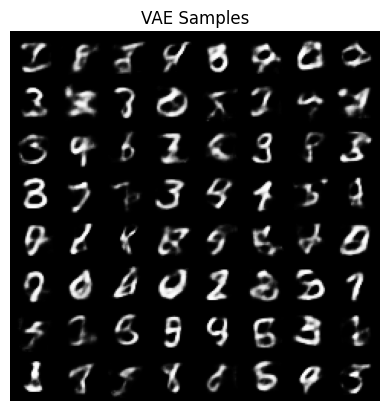

In [ ]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [ ]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [ ]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `Generator.forward`는 잠재벡터를 입력으로 받아 가짜 이미지를 생성하는 역할을 한다. 먼저, `ConvTranspose2d`를 사용하여 잠재벡터를 공간적인 이미지 형태로 변환하고, 각 층에서 이미지의 크기를 점점 늘려가면서 특징을 변환한다. 이 과정에서 `BatchNorm2d`와 `ReLU`를 적용하여 비선형적인 특징을 학습하며, 마지막으로 `tconv4`를 통과하면 `tanh`를 적용하여 최종 이미지를 생성한다.


In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `Discriminator.forward`는 입력된 이미지가 실제 이미지인지 가짜 이미지인지 판별하는 역할을 한다. 먼저, `Conv2d`를 통해 이미지의 특징을 추출하고, 각 층에서 이미지의 크기를 점점 줄여가며 중요한 특징을 학습한다. `conv2`와 `conv3` 이후에 있는 `BatchNorm2d`와 `LeakyReLU`를 적용하여 비선형적 특징을 학습한다. 마지막으로는 `conv4`와 `sigmoid`를 통해 이미지가 진짜일 확률을 출력한다.


In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [ ]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7403 | Loss G: 1.8669
Epoch [2/15] Loss D: 0.8716 | Loss G: 1.4988
Epoch [3/15] Loss D: 0.9335 | Loss G: 1.4189
Epoch [4/15] Loss D: 1.0038 | Loss G: 1.3173
Epoch [5/15] Loss D: 0.9688 | Loss G: 1.3857
Epoch [6/15] Loss D: 0.9777 | Loss G: 1.3957
Epoch [7/15] Loss D: 0.9637 | Loss G: 1.4223
Epoch [8/15] Loss D: 0.9718 | Loss G: 1.4205
Epoch [9/15] Loss D: 0.9703 | Loss G: 1.4278
Epoch [10/15] Loss D: 0.9462 | Loss G: 1.4812
Epoch [11/15] Loss D: 0.9397 | Loss G: 1.4979
Epoch [12/15] Loss D: 0.9307 | Loss G: 1.5190
Epoch [13/15] Loss D: 0.9270 | Loss G: 1.5404
Epoch [14/15] Loss D: 0.9002 | Loss G: 1.5835
Epoch [15/15] Loss D: 0.8917 | Loss G: 1.6091


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  이 코드는 GAN의 학습 과정을 나타내며. 실제 이미지는 1, 가짜 이미지는 0을 정답으로 설정하여 Discriminator가 실제 이미지와 가짜 이미지를 정확하게 구분할 수 있도록 학습한다. 위에서 채운 코드는 Generator가 생성한 이미지를 Discriminator에 입력하고 정답을 1로 설정한 것으로, Generator가 만든 이미지를 Discriminator가 진짜 이미지로 판단하도록 학습하게 된다. 또한 마지막으로 각 단게에서 계산한 loss를 이용해 두 모델의 파라미터를 갱신한다.


**DCGAN Sampling 시각화**

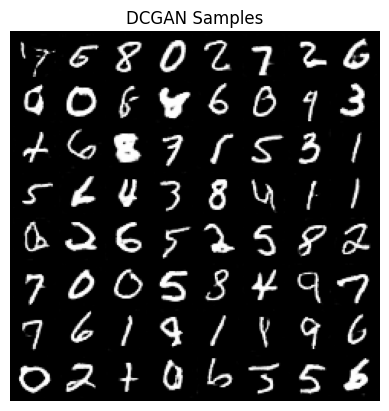

In [ ]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

*  VAE는 입력 이미지의 특징을 잠재공간의 확률분포로 압축한 후 decoder를 통해 이를 다시 복원하는 방식으로 학습한다. 이때 Reconstruction Loss는 원본과 본원된 이미지 간 픽셀 단위 차이로, 여러가지 출력 가능성에 대한 평균을 최소화하는 방식으로 학습되기 때문에 결과적으로 흐릿한 이미지가 생성되게 된다.또한 encoder에서 reparameterization trick을 통해 잠재벡터를 얻는 과정에서 노이즈가 개입되어 정보가 손실되는 문제가 발생할 수 있다.
반면, GAN은 적대적 학습 방식을 통해 Generator와 Discriminator가 서로 경쟁하며 학습하기 때문에 진짜 데이터 분포와 구별하기 어려운 이미지를 생성하는 데 집중하므로 더 선명하고 고해상도의 이미지를 생성할 수 있다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

*  Generator와 Discriminator 중 한 쪽이 너무 빨리 강해지면 서로 경쟁하며 학습하는 과정에서 균형이 깨질 수 있다. 예를 들어 Discriminator가 너무 빨리 강해지면 진짜 이미지와 가짜 이미지를 거의 완벽하게 구분해내기 때문에 Generator에 전달되는 gradient가 0에 가까워지는 Vanishing gradient 문제가 발생한다. 반대로 Generator가 너무 강해지면 Generator가 Discriminator를 잘 속이는 특정 패턴만 반복하기 때문에 잠재공간을 바꾸어도 비슷한 이미지만 계속 생성하게 되는 Mode collapse 문제가 발생한다.


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [ ]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `forward_diffusion`은 원본 이미지 `x0`에 `timestamp t` 만큼의 노이즈를 추가해 노이즈가 섞인 이미지 `x_t`를 만드는 역할을 한다. `torch.randn_like(x0)`를 이용해 원본 이미지와 같은 크기의 랜덤 노이즈를 생성한 후 `sqrt_alphas_cumprod[t]`와 `sqrt_one_minus_alphas_cumprod[t]`를 이용해 원본 이미지와 노이즈에 각각 적용할 비율을 계산하고 `sqrt_ac * x0 + sqrt_omac * noise` 수식에 따라 두 값을 결합한다. 따라서 `timestamp t`가 증가할수록 원본 이미지의 비중은 감소하고 점차 노이즈가 많은 이미지가 생성된다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

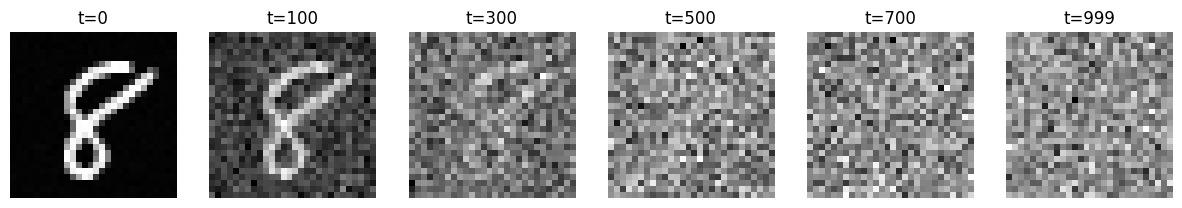

In [ ]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `SimpleUNet.forward`에서는 현재 이미지가 diffusion 과정의 몇 번째 timestep에 해당하는지 알려주기 위헤 timestep embedding을 bottleneck 채널에 더해준다. 이를 위해 `t`를 `TimeEmbedding`과 `Linear`를 통해 임베딩하여 timestep의 정보를 `t_emb`로 변환하고 `time_proj`를 이용해 `t_emb`를 bottleneck의 채널 수에 맞춘 후 `unsqeeze`를 통해 `h3`에 더할 수 있도록 변환한다. 이후 `t_proj`를 `h3`에 더하여 모델이 현재 timestep에 맞게 노이즈를 제거하도록 한다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [ ]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  `ddpm_loss`는 DDPM에서 모델이 이미지에 추가된 노이즈를 얼마나 잘 예측하는지를 학습하기 위한 loss이다. 먼저 각 이미지마다 임의의 timestep `t`를 선택하고, `forward_diffusion`을 통해 원본 이미지에 노이즈를 추가하여 `x_t`를 만든다. 이후 모델에 `x_t`와 `t`를 입력하여 노이즈를 예측하고, MSE Loss를 사용하여 실제 노이즈와 예측한 노이즈의 오차를 계산한다. 이를 통해 모델이 주어진 추가된 노이즈를 정확하게 예측하도록 학습한다.


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* Diffusion 과정에서 노이즈가 추가된 이미지는 `x_t`와 timestep `t`를 이용하여 노이즈 $\epsilon$을 정확하게 예측할 수 있다면 원본 이미지  $x_0$을 역으로 계산할 수 있다. 따라서 노이즈 $\epsilon$을 예측하는 것만으로도 원본 이미지를 복원할 수 있다.

In [ ]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [ ]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

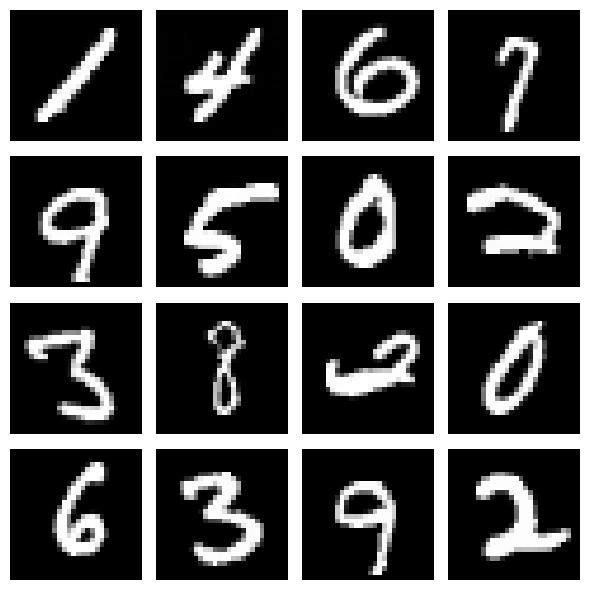

In [ ]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- DDPM의 생성 결과가 VAE나 GAN보다 일관적이지 않은 이유는 생성 과정에서 랜덤 노이즈를 시작점으로 하고 이후 노이즈를 여러 번에 걸쳐 점진적으로 제거하는 방식으로 이미지를 생성하기 때문이다. 따라서 매번 다른 노이즈에서 시작하기 때문에 생성 결과가 일관적이지 않을 수 있다. 반면 VAE는 입력 이미지를 잠재공간으로 압축한 후 잠재벡터를 Decoder에 통과시켜 한 번에 이미지를 복원하고, GAN은 Generator가 잠재벡터를 입력받아 한 번에 이미지를 생성하도록 학습한다. 따라서 VAE와 GAN은 DDPM과 달리 비교적 일관된 형태의 이미지를 생성할 수 있다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...


*   학습 안정성: VAE는 Reconstruction Loss와 KL Divergence를 이용하여 비교적 안정적으로 학습되는 반면 GAN은 Generator와 Discriminator가 서로 경쟁하며 학습하기 때문에 두 모델의 균형을 맞추어야 하며, Mode Collapse나 Vanoshing gradient와 같은 문제가 발생할 수 있다. Diffusion은 각 timestep에서 노이즈를 예측하는 것으로, GAN보다 비교적 안정적으로 학습할 수 있다.


*   생성 품질: VAE는 잠재공간의 정규화와 복원 과정으로 인해 이미지가 흐릿하게 생성될 수 있으며, GAN은 실제 이미지와 구별하기 어려운 이미지를 생성하도록 학습하기 때문에 고해상도의 선명한 이미지를 생성할 수 있다. Diffusion은 노이즈를 단계적으로 제거하면서 이미지를 생성하기 때문에 매우 높은 품질과 다양한 이미지를 생성할 수 있다.
*   추론 속도: VAE와 GAN는 잠재벡터를 Decoder 또는 Generator에 한 번만 통과시키기 때문에 추론 속도가 매우 빠른 반면, Diffusion은 랜덤 노이즈에서 시작하여 여러 timestep에 걸쳐 반복적으로 노이즈를 제거하는 과정이 필요하므로 상대적으로 추론 속도가 느리다.






## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [ ]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [ ]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

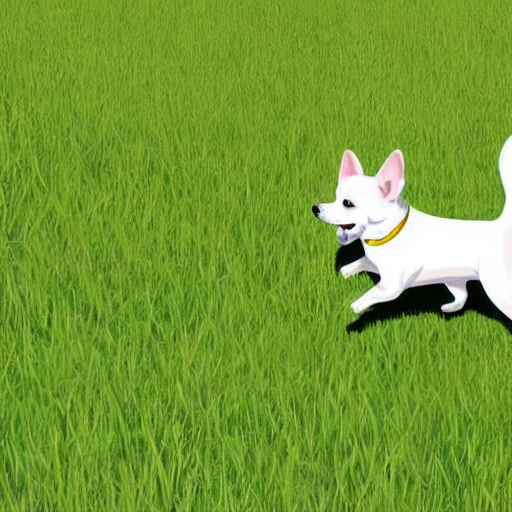

In [ ]:
prompt = "A cute 2D cartoon illustration of a white Chihuahua happily running and playing in a green grassy field, side view, full body, adorable and playful, soft pastel colors, clean line art."   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=50,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

*  `num_inference_steps`는 이미지 생성 과정에서 노이즈를 제거하는 횟수를 의미하며, 값이 작으면 이미지가 빠르게 생성되지만 노이즈가 충분히 제거되지 않아 이미지의 품질이 떨어질 수 있다. 반대로 값이 너무 크면 이미지 생성 시간이 오래 걸리지만 노이즈를 더 세밀하게 제거할 수 있으므로 이미지 품질이 좋아질 수 있다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

*  `guidance_scale`은 프롬프트를 생성 결과에 얼마나 강하게 반영할지를 조절하는 값으로, 값을 낮추면 프롬프트의 영향이 약해져 생성 결과가 프롬프트와 상대적으로 덜 관련될 수 있다. 반대로 이 값을 높이면 프롬프트를 강하게 따르기 때문에 프롬프트에서 설정한 조건이 더 강하게 반영될 수 있으나, 이미지가 부자연스럽거나 과하게 강조된 결과가 나타날 수 있다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

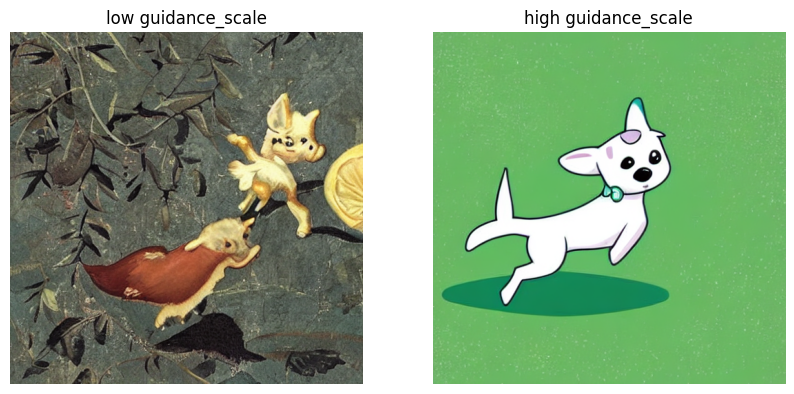

In [ ]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "A cute 2D cartoon illustration of a white Chihuahua happily running and playing in a green grassy field, side view, full body, adorable and playful, soft pastel colors, clean line art."

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*  위 코드는 동일한 프롬프트를 사용하지만 `guidance_scale` 값에 따라 이미지 생성 결과가 달라졌다. `guidance_scale`를 1,0으로 낮게 설정한 경우 `guidance_scale` 를 15.0으로 설정한 경우에 비해 프롬프트에서 지시한 조건을 잘 반영하지 못한 모습을 보인 것으로 확인할 수 있다.


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

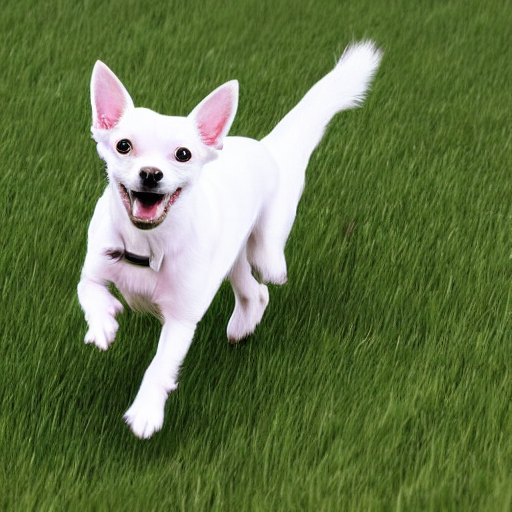

In [ ]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

*  DDPM의 reverse process는 노이즈가 많은 이미지에서 시작하여 각 timestep마다 모델이 노이즈를 예측하여 조금씩 제거하면서 원본을 복원하는 방식으로 진행한다. 따라서 노이즈를 제거하는 데 많은 timestep이 필요하지만 DDIM은 DDPM의 reverse process처럼 모든 timestep을 거치지 않고 일부 timestep을 건너뛰어 더 적은 step만으로도 노이즈를 제거할 수 있다. 따라서 DDIM은 DDPM에 비해 적은 step으로도 그럴듯한 이미지를 생성할 수 있어 이미지 생성 속도를 크게 높일 수 있다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)



*   **허깅페이스의 모델 api 활용하기**
https://colab.research.google.com/drive/1FhlkjCej_DNODPgu2PFf6Asijq_M8b5k?usp=sharing
1. 사용 데이터셋: food-101 (101개의 음식 종류에 대한 이미지 데이터셋)
https://huggingface.co/datasets/ethz/food101

2. 사용 모델: `nateraw/food` → ImageNet으로 사전 학습된 ViT-Base 모델을 food101 데이터로 파인튜닝한 이미지 분류 모델
https://huggingface.co/nateraw/food
3. 후기

평가 샘플 수: 1000<br>
Top-1 Accuracy: 89.60% <br>
Top-5 Accuracy: 97.60%<br>
101개의 매우 많은 카테고리임에도 불구하고 Top-1 정확도가 90%에 가까운 좋은 결과를 보였다. 틀린 예시들을 보면 대부분 같은 재료이거나 비슷한 형태의 음식인 경우가 많았는데 101개의 클래스 중 서로 유사하게 보이는 음식들이 존재하기 때문인 것으로 해석하였다.

이 데이터셋을 사용하기 전 human action 분류 데이터셋을 사용하려고 했었는데, 정확한 라벨이 있어야 할 test split이 알고 보니 전부 0번 클래스로 채워져 있어서 정상적인 평가 자체가 불가능한 상황이었다. 결국 시간 안에 해결하기 어려울 것 같아 다른 데이터셋으로 변경하였는데, 추후에 여유가 된다면 위 데이터셋을 가지고 다시 도전해보고 싶다.



## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): PyTorch 문법 디버깅이나 개념 설명에 사용하였습니다.

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 이 과제에서 틀린 답을 준 사례는 없었지만 개념 설명이나 코드에 대한 설명을 물어볼 때는 직접 자료를 찾아보며 공식 문서와 대조하였다.

- **실제 대화 내역** 붙여넣기:

```
풀밭에서 뛰어노는 하얀색 치와와의 고화질 이미지를 영어로 바꿔줘
```
```
“풀밭에서 뛰어노는 하얀색 치와와의 고화질 이미지”는 영어로:

“A high-quality image of a white Chihuahua running and playing in a grassy field.” 🐶🌱

이미지 생성 프롬프트로는 조금 더 자연스럽게:

A high-quality image of a white Chihuahua happily running and playing in a green grassy field, adorable and energetic.

만화풍을 원하면 image 대신 cute cartoon illustration로 바꾸면 돼.

조금 무서운데 정면 말고 옆모습..

응, 그럼 정면을 피하고 자연스럽게 옆으로 뛰는 모습을 명확하게 넣으면 돼. 🐶

A high-quality image of a cute white Chihuahua happily running and playing in a green grassy field, side view, looking to the side, full body, natural pose, adorable and playful.

만화풍이면:

A cute 2D cartoon illustration of a white Chihuahua happily running and playing in a green grassy field, side view, full body, adorable and playful, soft pastel colors, clean line art.

특히 **side view, full body, natural pose**를 넣는 게 중요해. 정면 얼굴 위주로 나오는 걸 꽤 잘 막아줘.
```
```
def elbo_loss(x, recon_x, mu, logvar): B = x.size(0) x = x.view(-1, 784) BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B # 🤔 빈칸을 채워주세요 KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B # 🤔 빈칸을 채워주세요 total_loss = BCE + KLD # 🤔 빈칸을 채워주세요 return total_loss 여기서 x.view(-1, 784)랑 mu.pow(2) 가 정확히 무슨 의미야?
```
```
응, 이 두 개는 VAE 코드에서 처음 보면 제일 헷갈리는 부분이야. 각각 완전히 다른 의미야.

1. x.view(-1, 784)
x = x.view(-1, 784)

이건 이미지의 모양(shape)을 펼치는 것이야.

MNIST 이미지가 보통:

x.shape = (B, 1, 28, 28)

이라고 하면,

B = 배치 크기
1 = 흑백 채널
28 × 28 = 이미지 크기

야.

그런데 VAE의 첫 번째 레이어가:

self.fc1 = nn.Linear(input_size=784, hidden_size=400)

이므로 입력이 784개의 숫자로 펼쳐진 형태여야 해.

그래서

x.view(-1, 784)

를 하면:

(B, 1, 28, 28)
       ↓
(B, 784)

가 돼.

여기서 -1은 PyTorch가 B 값을 알아서 계산하라는 의미야.

예를 들어 batch size가 64라면:

x.shape
# (64, 1, 28, 28)

x.view(-1, 784).shape
# (64, 784)

즉, 이미지 한 장을 28×28 → 784개의 숫자로 펼치는 것이라고 생각하면 돼.

2. mu.pow(2)
mu.pow(2)

는 mu의 각각의 값을 제곱한다는 뜻이야.

예를 들어:

mu = torch.tensor([1., 2., -3.])

라면

mu.pow(2)

결과는

[1, 4, 9]

이 돼.

즉,

mu.pow(2)

≒

mu ** 2

이야.

그런데 왜 mu를 제곱할까?

이건 KL Divergence 공식 때문에 그래.

VAE에서 잠재변수의 분포를

$$ q(z|x)=N(\mu,\sigma^2) $$

로 만들고, 이를 표준정규분포

$$ N(0,1) $$

에 가깝게 만들려고 해.

KL Divergence 공식에 μ² 항이 들어가기 때문에 코드에서도:

KLD = -0.5 * torch.sum(
    1 + logvar - mu.pow(2) - logvar.exp()
) / B

처럼 mu.pow(2)를 사용하는 거야.

직관적으로 보면 mu가 0에서 너무 멀어지지 않도록 패널티를 주는 역할이라고 생각하면 돼.

둘을 한 번에 정리하면
코드	의미	왜 필요한가
x.view(-1, 784)	(B,1,28,28) → (B,784)로 펼침	Linear(784,400)에 넣기 위해
mu.pow(2)	mu의 각 원소를 제곱	KL Divergence 공식의 μ² 항

특히 view는 데이터의 값을 바꾸는 게 아니라 모양(shape)을 바꾸는 것이고, pow(2)는 실제 값들을 제곱하는 연산이라는 차이를 기억하면 좋아.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 기존 예시와 다른 새로운 프롬프트를 넣는 과정에서 GPT가 제안하는 표현을 조금씩 바꾸거나 추가하며 원하는 이미지를 생성하려고 했다.


수고하셨습니다 ☺️